# Preliminary EDA: Durham Policing Data

## City & County of Durham, NC
https://live-durhamnc.opendata.arcgis.com/datasets/c55a356fa8ea49d3a8898c67f9282435/about

### Initial Metrics

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import contextily as ctx

df = pd.read_csv("../data/raw/dpd_calls_for_service_2025.csv")
df.head()

ModuleNotFoundError: No module named 'geopandas'

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 275117 entries, 0 to 275116
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Event Number  275117 non-null  int64  
 1   Case Number   39183 non-null   float64
 2   Call Date     275117 non-null  str    
 3   Call Time     275117 non-null  str    
 4   Source        275117 non-null  str    
 5   Priority      215337 non-null  str    
 6   Nature        275117 non-null  str    
 7   Address       274342 non-null  str    
 8   X             275117 non-null  float64
 9   Y             275117 non-null  float64
 10  District      264337 non-null  str    
 11  Beat          264341 non-null  str    
 12  Tract         264888 non-null  float64
 13  Disposition   275117 non-null  str    
 14  Cancelled     275117 non-null  int64  
dtypes: float64(4), int64(2), str(9)
memory usage: 31.5 MB


In [ ]:
df.describe()

,Event Number,Case Number,X,Y,Tract,Cancelled
count,2.751170e+05,3.918300e+04,2.751170e+05,2.751170e+05,264888.000000,275117.000000
mean,2.522742e+07,2.532347e+07,2.029142e+06,8.454318e+05,1530.373063,0.149584
std,1.314032e+05,2.808017e+07,1.311765e+06,1.279410e+06,694.371985,0.356663
min,2.500000e+07,2.500000e+01,0.000000e+00,0.000000e+00,101.000000,0.000000
25%,2.511357e+07,2.500954e+07,2.020041e+06,8.000523e+05,1100.000000,0.000000
50%,2.522659e+07,2.501916e+07,2.028909e+06,8.145859e+05,1710.000000,0.000000
75%,2.534084e+07,2.502880e+07,2.033733e+06,8.234798e+05,2020.000000,0.000000
max,2.545698e+07,2.511260e+09,3.144940e+07,3.082154e+07,9801.000000,1.000000


In [ ]:
df.nunique()

Event Number    275117
Case Number      38403
Call Date          365
Call Time        80281
Source              16
Priority            10
Nature             267
Address          22769
X               266440
Y               267585
District             6
Beat                37
Tract               60
Disposition         27
Cancelled            2
dtype: int64

In [ ]:
df.isna().sum()

Event Number         0
Case Number     235934
Call Date            0
Call Time            0
Source               0
Priority         59780
Nature               0
Address            775
X                    0
Y                    0
District         10780
Beat             10776
Tract            10229
Disposition          0
Cancelled            0
dtype: int64

In [ ]:
df['Disposition'].value_counts()

Disposition
Resolved Without Report             145385
Incident Report                      24628
Cell Phone Hang Up                   15708
{Other}                              15627
Unfounded                            12708
Cancelled                            12154
Accident Report                      10799
False Alarm                           8863
Citation Issued                       5092
(blank)                               4846
Verbal Warning                        4186
Referred Elsewhere                    3485
Duplicate Event                       2741
CIT - No Report                       2692
Information Relayed                   1245
Assist/Backup Unit                    1199
Test Entry                            1167
Refusal To Stop                        633
Entered As BOLO                        555
Police Not Needed                      477
Written Warning                        393
CIT - Incident Report                  185
Property Report                        145

### Feature Cleaning & Engineering

In [ ]:
df.drop(columns=['Event Number', 'Case Number', 'Beat', 'Tract'], inplace=True)
mask = df.notnull().all(axis=1)
df = df[mask]
df.isna().sum()

Call Date      0
Call Time      0
Source         0
Priority       0
Nature         0
Address        0
X              0
Y              0
District       0
Disposition    0
Cancelled      0
dtype: int64

In [ ]:
df['datetime'] = pd.to_datetime(
    df['Call Date'] + ' ' + df['Call Time'],
    format='%m/%d/%Y %I:%M:%S%p'
)
df['datetime'].head()

0   2025-01-01 00:01:02
1   2025-01-01 00:01:06
2   2025-01-01 00:01:35
3   2025-01-01 00:01:48
4   2025-01-01 00:02:43
Name: datetime, dtype: datetime64[us]

In [ ]:
df.drop(columns=['Call Date', 'Call Time'], inplace=True)

In [ ]:
df.head()

,Source,Priority,Nature,Address,X,Y,District,Disposition,Cancelled,datetime
0,Wireless 911 Call,2,SOUND OF SHOTS,400 CHESTNUT OAK PL,2055296.139,825122.6138,D1,Unfounded,0,2025-01-01 00:01:02
1,Phone Call,2,SOUND OF SHOTS,E CORNWALLIS RD/S ROXBORO ST,2023925.921,806242.4230,D4,Resolved Without Report,0,2025-01-01 00:01:06
2,Wireless 911 Call,2,SOUND OF SHOTS,1300 RIPLEY ST,2022632.342,814383.9936,D3,Resolved Without Report,0,2025-01-01 00:01:35
3,Wireless 911 Call,2,SOUND OF SHOTS,ELMWOOD AVE/JERSEY AVE,2021199.012,814813.0050,D3,Resolved Without Report,0,2025-01-01 00:01:48
4,Wireless 911 Call,2,SOUND OF SHOTS,3300 GLASSON ST,2013092.903,820695.4059,D3,Resolved Without Report,0,2025-01-01 00:02:43


In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 207383 entries, 0 to 275115
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Source       207383 non-null  str           
 1   Priority     207383 non-null  str           
 2   Nature       207383 non-null  str           
 3   Address      207383 non-null  str           
 4   X            207383 non-null  float64       
 5   Y            207383 non-null  float64       
 6   District     207383 non-null  str           
 7   Disposition  207383 non-null  str           
 8   Cancelled    207383 non-null  int64         
 9   datetime     207383 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(1), str(6)
memory usage: 17.4 MB


In [ ]:
df['Priority'] = df['Priority'].map({
    '9': 0,
    '8': 1,
    '7': 2,
    '6': 3,
    '5': 4,
    '4': 5,
    '3': 6,
    '2': 7,
    '1': 8,
    'P': 9
})

In [ ]:
for col in ['Nature', 'District', 'Disposition']:
    df[col] = df[col].astype('category')

In [ ]:
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()
df['month'] = df['datetime'].dt.to_period('M')
df['date'] = df['datetime'].dt.date

In [ ]:
df.info()
%store df


<class 'pandas.DataFrame'>
Index: 207383 entries, 0 to 275115
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Source       207383 non-null  str           
 1   Priority     207383 non-null  int64         
 2   Nature       207383 non-null  category      
 3   Address      207383 non-null  str           
 4   X            207383 non-null  float64       
 5   Y            207383 non-null  float64       
 6   District     207383 non-null  category      
 7   Disposition  207383 non-null  category      
 8   Cancelled    207383 non-null  int64         
 9   datetime     207383 non-null  datetime64[us]
 10  hour         207383 non-null  int32         
 11  day_of_week  207383 non-null  str           
 12  month        207383 non-null  period[M]     
 13  date         207383 non-null  object        
dtypes: category(3), datetime64[us](1), float64(2), int32(1), int64(2), object(1), period[M](1), str(3)
m

### Visualization

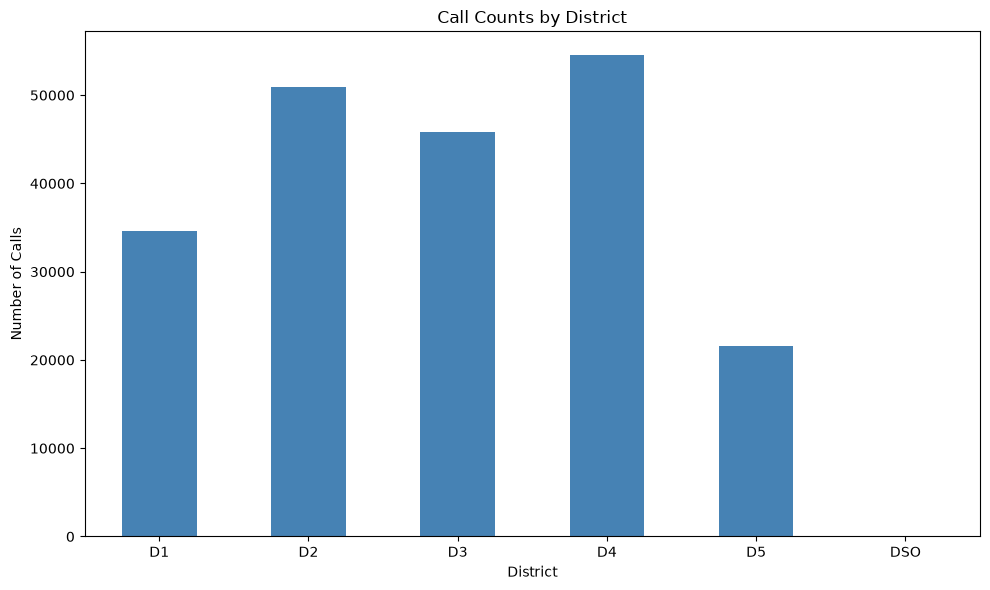

In [ ]:
district_counts = df['District'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
district_counts.plot(kind='bar', color='steelblue')
plt.title('Call Counts by District')
plt.xlabel('District')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

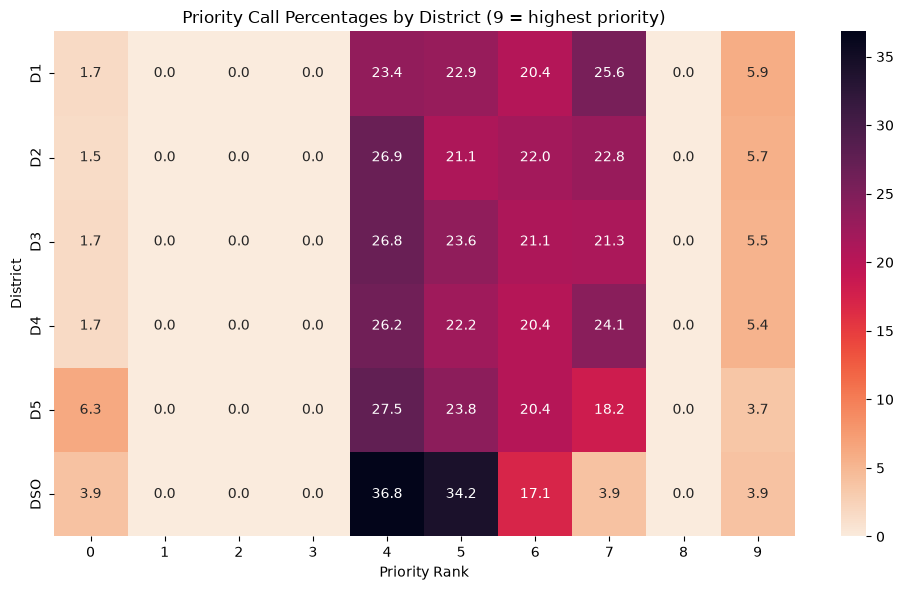

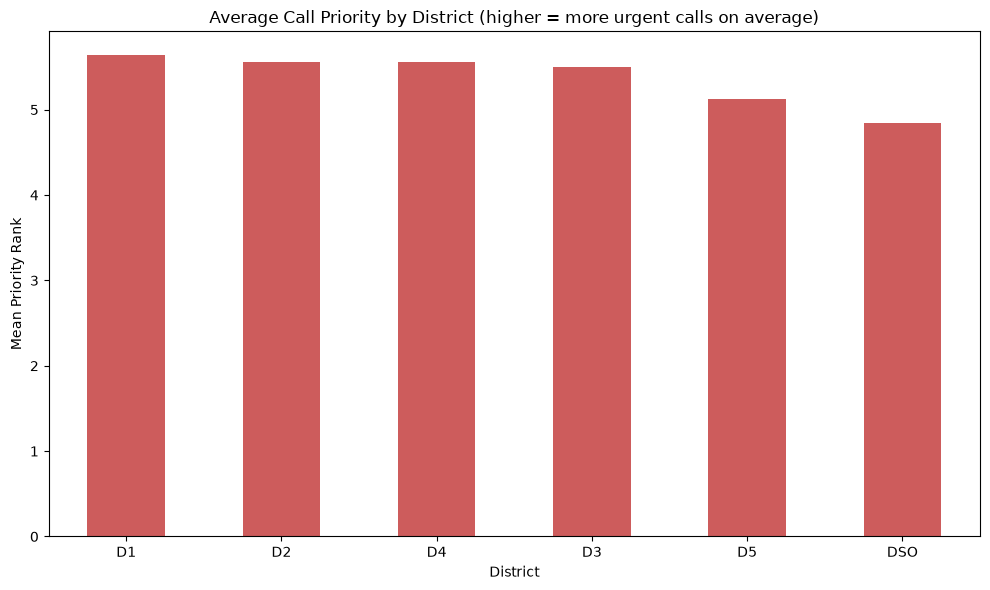

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Heatmap: % distribution of priority within each district (row-normalized)
pivot = pd.crosstab(df['District'], df['Priority'])
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='rocket_r')
plt.title('Priority Call Percentages by District (9 = highest priority)')
plt.xlabel('Priority Rank')
plt.ylabel('District')
plt.tight_layout()
plt.show()

# 2. Summary: mean priority rank by district — direct comparison, volume-adjusted
mean_priority = df.groupby('District', observed=True)['Priority'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
mean_priority.plot(kind='bar', color='indianred')
plt.title('Average Call Priority by District (higher = more urgent calls on average)')
plt.xlabel('District')
plt.ylabel('Mean Priority Rank')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Filter to plausible Durham-area coordinates in raw State Plane feet
df_valid = df[
    (df['X'].between(1_900_000, 2_200_000)) &
    (df['Y'].between(700_000, 900_000))
].copy()

print(f"Dropped {len(df) - len(df_valid)} rows with invalid coordinates")

gdf = gpd.GeoDataFrame(
    df_valid,
    geometry=gpd.points_from_xy(df_valid['X'], df_valid['Y']),
    crs='EPSG:2264'
).to_crs(epsg=3857)

print(gdf.crs)
print(gdf.total_bounds)

Dropped 1 rows with invalid coordinates
EPSG:3857
[-8794705.94787337  4282281.93571487 -8767450.23938409  4324814.04254518]


c:\Users\colby\aipi\sourcing_data\data_storytelling_project\data-storytelling-project\.venv\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]
c:\Users\colby\aipi\sourcing_data\data_storytelling_project\data-storytelling-project\.venv\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]
c:\Users\colby\aipi\sourcing_data\data_storytelling_project\data-storytelling-project\.venv\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can r

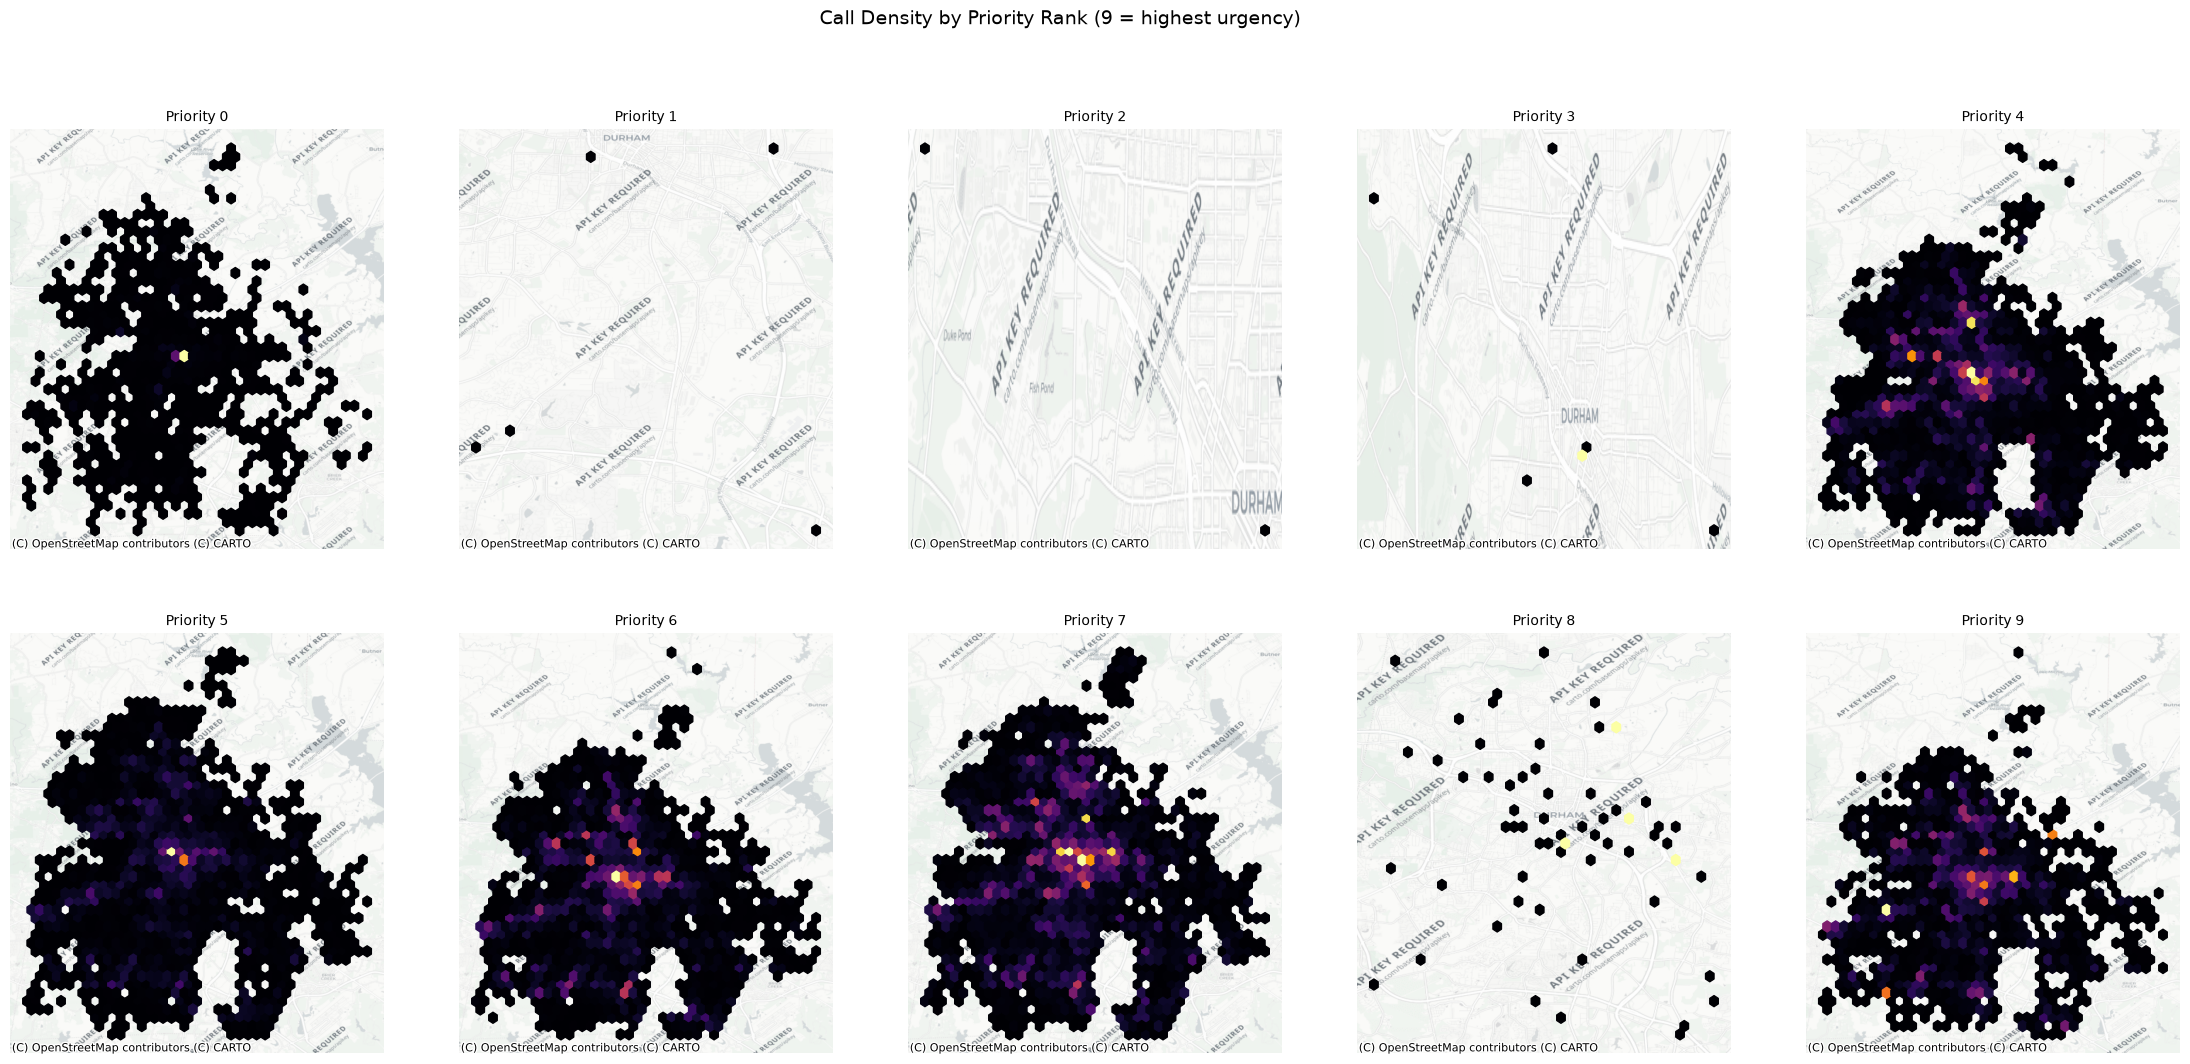

In [ ]:
gdf_valid = gdf.dropna(subset=['Priority'])
priorities = sorted(gdf_valid['Priority'].unique())

ncols = 5
nrows = -(-len(priorities) // ncols)  # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(28, 12))
axes = axes.flatten()

for ax, p in zip(axes, priorities):
    group = gdf_valid[gdf_valid['Priority'] == p]
    ax.hexbin(group.geometry.x, group.geometry.y, gridsize=40, cmap='inferno', mincnt=1)
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    ax.set_axis_off()
    ax.set_title(f'Priority {int(p)}', fontsize=10)

for ax in axes[len(priorities):]:
    ax.axis('off')

fig.suptitle('Call Density by Priority Rank (9 = highest urgency)', fontsize=14)

plt.show()

### Takeaways
1. Districts 2 and 4 recieve highest number of calls
2. District 1 is most prioritized.
3. Maybe switch to census tract to get wealth reading of areas
4. Maybe condense disposition into a few columns (resolved, unresolved, ?)
5. Crimes vs calls, if the crime reported is more than just the responded calls
6. Moderate crimes more distributed, but Priority 7 and 9 are clustered closer.